## 🎯 Problem Statement
Predict flight ticket prices based on airline, journey date, stops, etc.

## 🧪 Approach
We will:
- Clean the dataset
- Extract useful features
- Train regression models
- Evaluate performance

Imports

In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor
import pickle
import warnings
from warnings import filterwarnings
filterwarnings("ignore")
import plotly.express as px

Read data files

In [247]:
data_dir = Path.cwd() / "data"
train_path = data_dir / "Data_Train.csv"
test_path = data_dir / "Test_set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10683, 11)
Test shape: (2671, 10)


In [248]:
train_df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


**Data cleaning**

1. missing data
2. duplicate data
3. uncorrected data-types
4. irrelevant rows

In [249]:
train_df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [250]:
train_df[train_df["Total_Stops"].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [251]:
# Only 1 row has missing values → safe to drop
train_df = train_df.dropna()

In [252]:
train_df[train_df.duplicated(keep=False)].sort_values(by = train_df.columns.tolist())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
6321,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
9848,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
572,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
8168,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
1495,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
...,...,...,...,...,...,...,...,...,...,...,...
2870,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,05:45,08:35,2h 50m,non-stop,No check-in baggage included,4273
1535,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
3711,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
2634,Vistara,24/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,5403


In [253]:
train_df = train_df.drop_duplicates()

In [254]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10462 non-null  str  
 1   Date_of_Journey  10462 non-null  str  
 2   Source           10462 non-null  str  
 3   Destination      10462 non-null  str  
 4   Route            10462 non-null  str  
 5   Dep_Time         10462 non-null  str  
 6   Arrival_Time     10462 non-null  str  
 7   Duration         10462 non-null  str  
 8   Total_Stops      10462 non-null  str  
 9   Additional_Info  10462 non-null  str  
 10  Price            10462 non-null  int64
dtypes: int64(1), str(10)
memory usage: 980.8 KB


date feature engineering

In [255]:
data = train_df.copy()
data.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [256]:
data.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [257]:
data["Date_of_Journey"] = pd.to_datetime(data["Date_of_Journey"],  format='%d/%m/%Y')

In [258]:
data["Date_of_Journey"].dtype

dtype('<M8[us]')

In [259]:
data["Journey_day"] = data["Date_of_Journey"].dt.day
data["Journey_month"] = data["Date_of_Journey"].dt.month
data["Journey_year"] = data["Date_of_Journey"].dt.year

In [260]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019


In [261]:
data["Arrival_Time_hour"] = pd.to_datetime(data["Arrival_Time"]).dt.hour
data["Arrival_Time_minute"] = pd.to_datetime(data["Arrival_Time"]).dt.minute

In [262]:
data["Dep_Time_hour"] = pd.to_datetime(data["Dep_Time"]).dt.hour
data["Dep_Time_minute"] = pd.to_datetime(data["Dep_Time"]).dt.minute

In [263]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50


When do most of the flights take off?

In [264]:
def flight_dep_time(x):
    if 4 < x <= 8:
        return "Early Morning"
    elif 8 < x <= 12:
        return "Morning"
    elif 12 < x <= 16:
        return "Noon"
    elif 16 < x <= 20:
        return "Evening"
    elif 20 < x <= 24:
        return "Night"
    else:
        return "late Night"

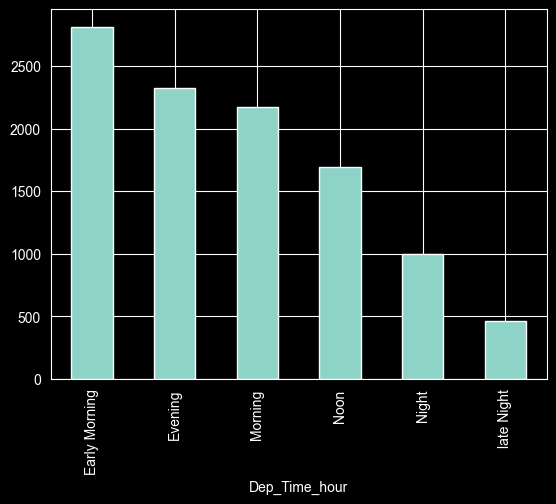

In [265]:
data["Dep_Time_hour"].apply(flight_dep_time).value_counts().plot(kind = "bar")
plt.show()

now to make the graphs a little more interactive we will install and use the following package

In [266]:
counts = data["Dep_Time_hour"].apply(flight_dep_time).value_counts().reset_index()
counts.columns = ["Dep_shift", "total_flights"]
counts

,Dep_shift,total_flights
0,Early Morning,2814
1,Evening,2323
2,Morning,2170
3,Noon,1696
4,Night,995
5,late Night,464


In [267]:
px.bar(data_frame= counts, x = "Dep_shift", y = "total_flights")

data preparation / data preprocessing

In [268]:
def preprocess_duration(x):
    if "h" not in x:
        x = '0h' + ' ' + x
    elif "m" not in x:
        x = x + ' ' + '0m'
    return x

In [269]:
data["Duration"] = data["Duration"].apply(preprocess_duration)

In [270]:
data["Duration_hour"] = pd.to_timedelta(data["Duration"]).dt.components.hours
data["Duration_minute"] = pd.to_timedelta(data["Duration"]).dt.components.minutes

In [271]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Arrival_Time_hour', 'Arrival_Time_minute',
       'Dep_Time_hour', 'Dep_Time_minute', 'Duration_hour', 'Duration_minute'],
      dtype='str')

In [272]:
cols_to_drop = ['Dep_Time', 'Arrival_Time', 'Duration', 'Date_of_Journey'] ##these columns have already been replaced by other columns
data.drop(cols_to_drop, axis = 1, inplace = True)

In [273]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Arrival_Time_hour', 'Arrival_Time_minute',
       'Dep_Time_hour', 'Dep_Time_minute', 'Duration_hour', 'Duration_minute'],
      dtype='str')

Does duration impact flight?

In [274]:
data["Duration_total_minutes"] = data["Duration_hour"] * 60 + data["Duration_minute"]

In [275]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Arrival_Time_hour', 'Arrival_Time_minute',
       'Dep_Time_hour', 'Dep_Time_minute', 'Duration_hour', 'Duration_minute',
       'Duration_total_minutes'],
      dtype='str')

<Axes: xlabel='Duration_total_minutes', ylabel='Price'>

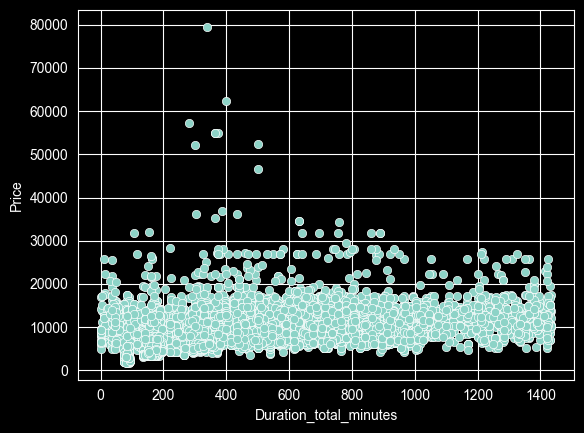

In [276]:
sns.scatterplot(data = data, x = "Duration_total_minutes", y = "Price")

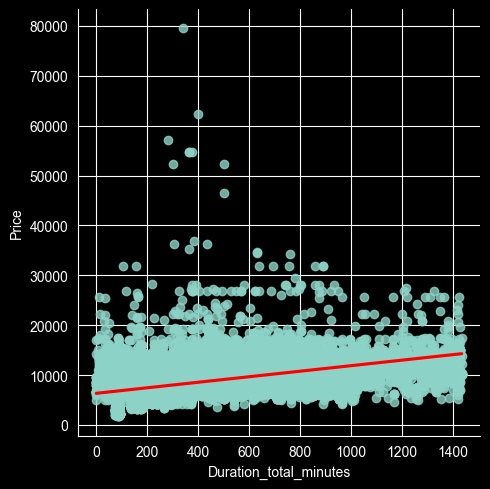

In [277]:
sns.lmplot(data = data, x = "Duration_total_minutes", y = "Price", line_kws={'color': 'red'})

the regression line has a positive slope it means more destination time most likely results in increased prices

In [278]:
m , c = np.polyfit(data["Duration_total_minutes"], data["Price"], 1) ## slope and intercept

In [279]:
m

np.float64(5.5357527297719376)

In [280]:
c

np.float64(6345.85254471688)

y = mc + b


price = 5.53 * duration + 6345.85

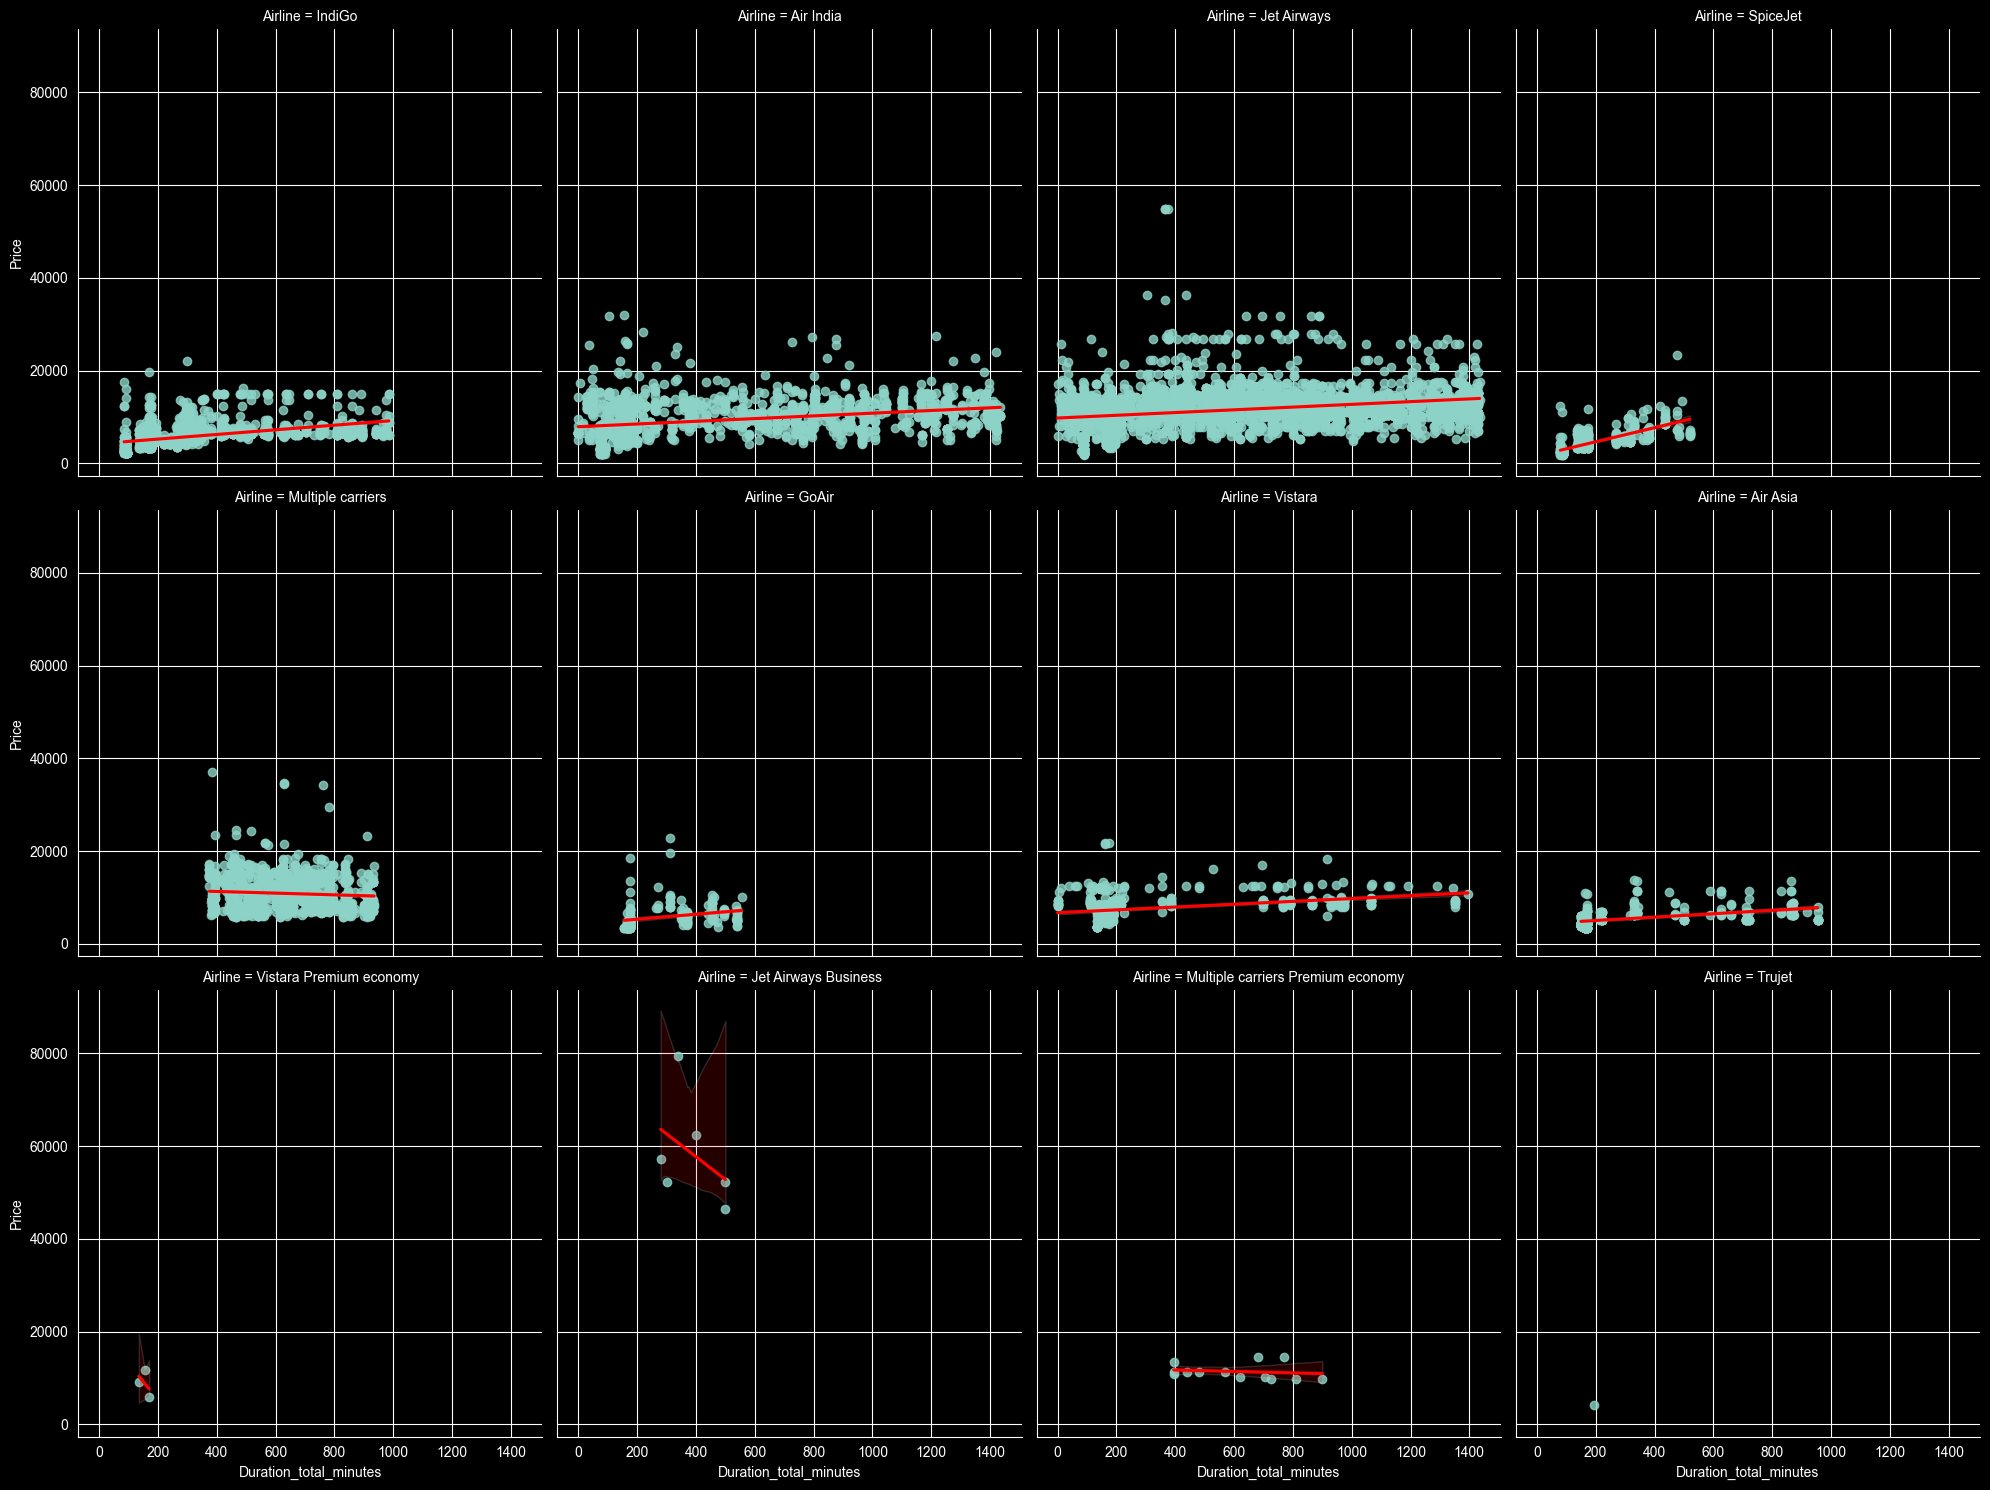

In [281]:
sns.lmplot(
    data=data,
    x="Duration_total_minutes",
    y="Price",
    col="Airline",
    col_wrap=4,
    line_kws={'color': 'red'}
)

one-hot Encoding

In [282]:
dataframe = data.copy()

In [283]:
data.dtypes

Airline                     str
Source                      str
Destination                 str
Route                       str
Total_Stops                 str
Additional_Info             str
Price                     int64
Journey_day               int32
Journey_month             int32
Journey_year              int32
Arrival_Time_hour         int32
Arrival_Time_minute       int32
Dep_Time_hour             int32
Dep_Time_minute           int32
Duration_hour             int64
Duration_minute           int64
Duration_total_minutes    int64
dtype: object

In [284]:
cat_col = [col for col in data.columns if data[col].dtypes == 'str']
num_col = [col for col in data.columns if data[col].dtypes != 'str']

In [285]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [286]:
data["Source"].unique()

<StringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [287]:
source_dummies = pd.get_dummies(data["Source"], prefix = "Source").astype(int)
source_dummies

,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,1,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,0,1,0
4,1,0,0,0,0
...,...,...,...,...,...
10678,0,0,0,1,0
10679,0,0,0,1,0
10680,1,0,0,0,0
10681,1,0,0,0,0


In [288]:
data = pd.concat([data, source_dummies], axis = 1)
data

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,...,Dep_Time_hour,Dep_Time_minute,Duration_hour,Duration_minute,Duration_total_minutes,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,...,22,20,2,50,170,1,0,0,0,0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,...,5,50,7,25,445,0,0,0,1,0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,2019,...,9,25,19,0,1140,0,0,1,0,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,2019,...,18,5,5,25,325,0,0,0,1,0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,2019,...,16,50,4,45,285,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,2019,...,19,55,2,30,150,0,0,0,1,0
10679,Air India,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,2019,...,20,45,2,35,155,0,0,0,1,0
10680,Jet Airways,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,2019,...,8,20,3,0,180,1,0,0,0,0
10681,Vistara,Banglore,New Delhi,BLR → DEL,non-stop,No info,12648,1,3,2019,...,11,30,2,40,160,1,0,0,0,0


In [289]:
data["Airline"].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [290]:
data.groupby(["Airline"])["Price"].mean().sort_values()

Airline
Trujet                                4140.000000
SpiceJet                              4335.841718
Air Asia                              5590.260188
IndiGo                                5668.469897
GoAir                                 5861.056701
Vistara                               7801.355649
Vistara Premium economy               8962.333333
Air India                             9556.608028
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11599.021081
Jet Airways Business                 58358.666667
Name: Price, dtype: float64

target guided mean -> airlines that have the highest avg prices gets higher priority

In [291]:
airlines = data.groupby(["Airline"])["Price"].mean().sort_values().index
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='str', name='Airline')

In [292]:
numbers = range(len(airlines))

In [293]:
dict_airlines = dict(zip(airlines, numbers))
dict_airlines

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [294]:
data["Airline"] = data["Airline"].map(dict_airlines)
 ## DO NOT RE EXECUTE

In [295]:
data["Airline"]

0         3
1         7
2        10
3         3
4         3
         ..
10678     2
10679     7
10680    10
10681     5
10682     7
Name: Airline, Length: 10462, dtype: int64

In [296]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [297]:
data["Destination"].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [298]:
data["Destination"] = data["Destination"].replace('New Delhi' , 'Delhi', inplace = True) ##only one airport

In [299]:
data["Destination"].unique()

<StringArray>
['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad']
Length: 5, dtype: str

In [300]:
destination = data.groupby(["Destination"])["Price"].mean().sort_values().index
destination

Index(['Kolkata', 'Hyderabad', 'Delhi', 'Banglore', 'Cochin'], dtype='str', name='Destination')

In [301]:
dict_destination = dict(zip(destination, numbers))
dict_destination

{'Kolkata': 0, 'Hyderabad': 1, 'Delhi': 2, 'Banglore': 3, 'Cochin': 4}

In [302]:
data["Destination"] = data["Destination"].map(dict_destination)

In [303]:
data["Destination"]

0        2
1        3
2        4
3        3
4        2
        ..
10678    3
10679    3
10680    2
10681    2
10682    4
Name: Destination, Length: 10462, dtype: int64

Preforming label encoding

In [304]:
data["Total_Stops"].unique()   ##ordinal data so one hot encoding won't work

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', '4 stops']
Length: 5, dtype: str

In [305]:
stop = {'non-stop' : 0, '2 stops' : 2, '1 stop' : 1, '3 stops' : 3, '4 stops' : 4}

In [306]:
data["Total_Stops"] = data["Total_Stops"].map(stop)
data["Total_Stops"]

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10462, dtype: int64

In [307]:
data.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,...,Dep_Time_hour,Dep_Time_minute,Duration_hour,Duration_minute,Duration_total_minutes,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,3,Banglore,2,BLR → DEL,0,No info,3897,24,3,2019,...,22,20,2,50,170,1,0,0,0,0
1,7,Kolkata,3,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,...,5,50,7,25,445,0,0,0,1,0


In [308]:
data["Additional_Info"].value_counts()/len(data)*100 ##80% have no info so column can be dropped

Additional_Info
No info                         78.206844
In-flight meal not included     18.409482
No check-in baggage included     3.039572
1 Long layover                   0.181610
Change airports                  0.066909
Business class                   0.038234
No Info                          0.028675
1 Short layover                  0.009558
Red-eye flight                   0.009558
2 Long layover                   0.009558
Name: count, dtype: float64

In [309]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Arrival_Time_hour', 'Arrival_Time_minute',
       'Dep_Time_hour', 'Dep_Time_minute', 'Duration_hour', 'Duration_minute',
       'Duration_total_minutes', 'Source_Banglore', 'Source_Chennai',
       'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai'],
      dtype='str')

In [310]:
data["Journey_year"].unique() ##only one value and can be dropped

array([2019], dtype=int32)

In [311]:
## columns to be dropped
columns = ['Additional_Info', 'Journey_year', 'Duration_total_minutes', 'Source', 'Route']

In [312]:
data.drop(columns = columns, inplace = True)

In [313]:
data.columns

Index(['Airline', 'Destination', 'Total_Stops', 'Price', 'Journey_day',
       'Journey_month', 'Arrival_Time_hour', 'Arrival_Time_minute',
       'Dep_Time_hour', 'Dep_Time_minute', 'Duration_hour', 'Duration_minute',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai'],
      dtype='str')

Handling outliers

In [314]:
def plot(df, col):
    fig , (ax1, ax2, ax3) = plt.subplots(3, 1)
    sns.distplot(df[col], ax = ax1)
    sns.boxplot(data = df, x= col, ax = ax2)
    sns.distplot(df[col], ax= ax3, kde=False)

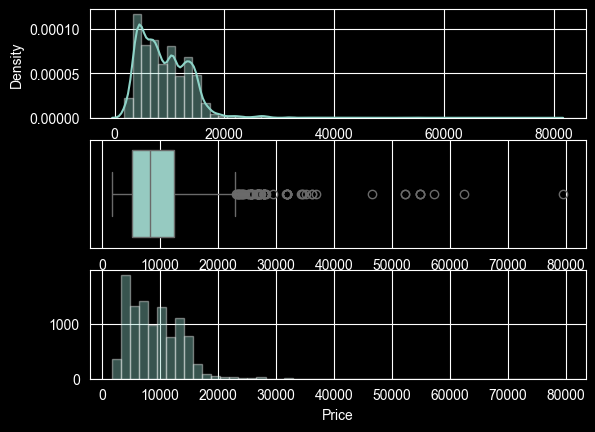

In [315]:
plot(data, "Price")

In [316]:
q1 = data["Price"].quantile(0.25)
q3 = data["Price"].quantile(0.75)

In [317]:
iqr = q3-q1
iqr

np.float64(7120.75)

In [318]:
maximum = q3 + 1.5*iqr ##max range for outlier
minimum = q1 - 1.5*iqr ##min range for outlier
maximum

np.float64(23025.875)

In [319]:
minimum

np.float64(-5457.125)

In [320]:
print([price for price in data["Price"] if price > maximum or price<minimum]) ## print outliers

[27430, 36983, 26890, 26890, 25139, 27210, 52229, 26743, 26890, 25735, 27992, 26890, 26890, 23583, 26890, 23533, 24115, 25735, 54826, 31783, 27992, 26890, 26890, 25430, 36235, 27210, 26890, 25735, 54826, 26890, 35185, 79512, 28097, 27992, 26890, 25735, 26092, 31825, 25913, 25735, 27992, 31825, 23267, 62427, 54826, 31825, 25430, 26890, 36235, 23843, 26890, 25735, 28322, 25735, 25735, 31825, 26890, 27992, 34273, 46490, 29528, 26890, 26890, 26890, 34503, 26890, 27992, 26890, 26890, 23170, 24528, 26890, 27992, 25735, 34608, 25703, 26890, 23528, 31825, 27282, 25735, 27992, 52285, 24017, 31945, 26890, 24318, 23677, 27992, 24210, 57209, 26890, 31825, 26480]


In [321]:
len([price for price in data["Price"] if price > maximum or price<minimum])

94

In [322]:
## example if the business analyst required a specific limit for outliers so we handled it using median approach
data["Price"] = np.where(data["Price"] >= 35000, data["Price"].median(), data["Price"])

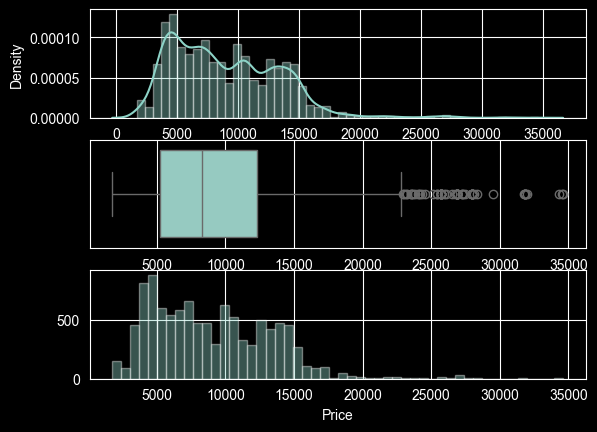

In [323]:
plot(data, "Price")

what other outlier tech can we use?

feature selection

In [324]:
data.columns

Index(['Airline', 'Destination', 'Total_Stops', 'Price', 'Journey_day',
       'Journey_month', 'Arrival_Time_hour', 'Arrival_Time_minute',
       'Dep_Time_hour', 'Dep_Time_minute', 'Duration_hour', 'Duration_minute',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai'],
      dtype='str')

In [325]:
X = data.drop(['Price'], axis = 1)

In [326]:
y = data["Price"]

In [327]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)

In [328]:
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [329]:
rf.feature_importances_

array([0.17016912, 0.02046213, 0.43925547, 0.13759114, 0.0588885 ,
       0.03070033, 0.02098897, 0.02743828, 0.02389793, 0.0320874 ,
       0.02140306, 0.00310527, 0.00123773, 0.00325404, 0.00464024,
       0.00488038])

In [330]:
X.columns

Index(['Airline', 'Destination', 'Total_Stops', 'Journey_day', 'Journey_month',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Dep_Time_hour',
       'Dep_Time_minute', 'Duration_hour', 'Duration_minute',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai'],
      dtype='str')

In [331]:
pd.DataFrame({"Feature" : X.columns, "Importance" : rf.feature_importances_}).sort_values(by = "Importance", ascending = False)

,Feature,Importance
2,Total_Stops,0.439255
0,Airline,0.170169
3,Journey_day,0.137591
4,Journey_month,0.058888
9,Duration_hour,0.032087
5,Arrival_Time_hour,0.030700
7,Dep_Time_hour,0.027438
8,Dep_Time_minute,0.023898
10,Duration_minute,0.021403
6,Arrival_Time_minute,0.020989


Model building using random forest

In [332]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [333]:
ml_model = RandomForestRegressor()

In [334]:
ml_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [335]:
y_pred = ml_model.predict(X_test)

In [336]:
y_pred

array([15211.76366667,  3836.55333333,  4269.21666667, ...,
       13840.11333333, 11527.137     ,  4039.28666667], shape=(2616,))

In [337]:
metrics.mean_absolute_error(y_test, y_pred)

1184.291510099631

In [338]:
metrics.r2_score(y_test, y_pred)

0.8095707038384912

In [339]:
metrics.mean_absolute_percentage_error(y_test, y_pred) ## flight fare predicted 13.4% away from actual price

0.13411449225300495

save the model in a pickle file instead of constantly re training it

In [340]:
with open(r"D:/data science projects/flight_prediction/models/rd_random.pkl", "wb") as file: ## change path as you wish
    pickle.dump(ml_model, file)

In [341]:
model = open(r"D:/data science projects/flight_prediction/models/rd_random.pkl", 'rb')

In [342]:
rf_random = pickle.load(model)

In [343]:
y_pred2 = rf_random.predict(X_test)

In [344]:
metrics.r2_score(y_test, y_pred2) ##confirming its the same model by confirming the same results

0.8095707038384912

test different models with machine learning pipeline

In [345]:
def predict(ml_model):
    model = ml_model.fit(X_train, y_train)
    print('Training score : {}'.format(model.score(X_train, y_train)))
    y_prediction = model.predict(X_test)
    print("predictions are : {} ".format(y_prediction))

    print('\n')
    r2_score = metrics.r2_score(y_test, y_prediction)
    print("R2 score : {}".format(r2_score))
    print("MAE : {}".format(metrics.mean_absolute_error(y_test, y_prediction)))
    print("MAPE : {}".format(metrics.mean_absolute_percentage_error(y_test, y_prediction)))
    sns.distplot(y_test - y_prediction)

Training score : 0.9523662036229034
predictions are : [15320.92952381  3842.76        4273.09666667 ... 13633.44
 11494.72416667  4025.27166667] 


R2 score : 0.8089835696158347
MAE : 1183.7268897281576
MAPE : 0.13387969710052391


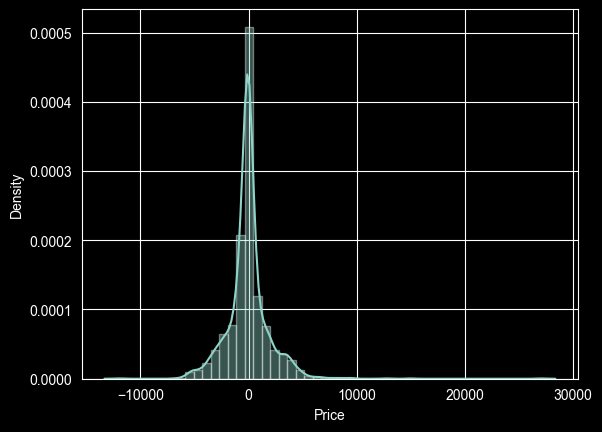

In [346]:
predict(RandomForestRegressor())

Training score : 0.9678875584094965
predictions are : [14158.5  3841.   4148.  ... 14151.  10844.   3841. ] 


R2 score : 0.6957022083888187
MAE : 1378.4380733944954
MAPE : 0.15331783288486078


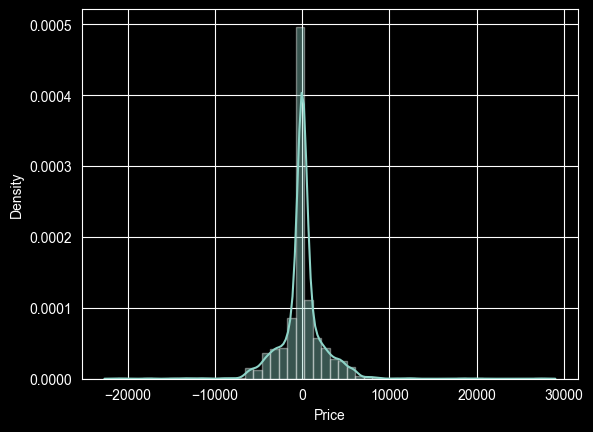

In [347]:
predict(DecisionTreeRegressor())

## 📌 Conclusion

- RandomForest performed best with R2 = 0.85
- Price strongly depends on:
  - Total stops
  - Airline
  - Duration
- Future improvements:
  - More feature engineering
  - Try XGBoost